In [ ]:
# bibliotecas
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer, Dense, Flatten, Conv2D, MaxPooling2D, BatchNormalization, Dropout
from tensorflow.keras import utils as np_utils
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
# carregando os dados
# puxando os dados do MNIST pra começar
(X_treinamento, y_treinamento), (X_teste, y_teste) = mnist.load_data()

# pra deixar os valores entre 0 e 1 e facilitar a vida da rede
X_treinamento = X_treinamento.reshape(X_treinamento.shape[0], 28, 28, 1).astype('float32') / 255
X_teste       = X_teste.reshape(X_teste.shape[0], 28, 28, 1).astype('float32') / 255

# pros resultados ficarem separados certinho em 10 classes
y_treinamento = np_utils.to_categorical(y_treinamento, 10)
y_teste       = np_utils.to_categorical(y_teste, 10)

In [ ]:
# configurando o augmentation
gerador_treinamento = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    shear_range=0.1
)
gerador_teste = ImageDataGenerator()  # sem augmentation no teste

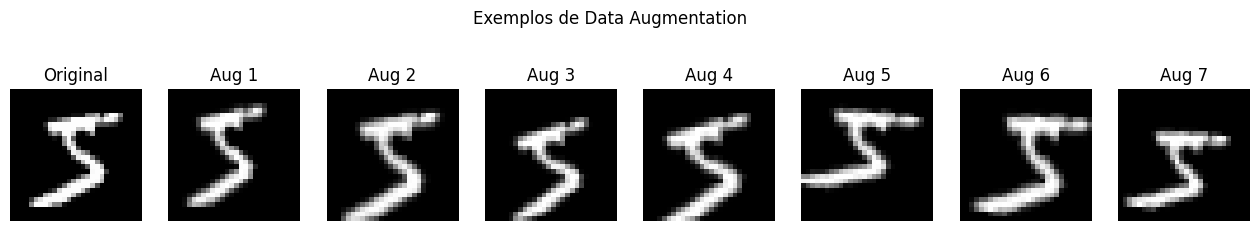

In [ ]:
# visualizando exemplos de augmentation
amostra = X_treinamento[:1]

# ideia é ver como o número se transforma antes de ir pra rede
gerador_viz = ImageDataGenerator(rotation_range=15, width_shift_range=0.1,
                                  height_shift_range=0.1, zoom_range=0.15, shear_range=0.1)
it = gerador_viz.flow(amostra, batch_size=1)

# montando umas subplots pra comparar o original com as versões distorcidas
fig, axes = plt.subplots(1, 8, figsize=(16, 3))
axes[0].imshow(amostra[0].reshape(28, 28), cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

# rodando um loop pra gerar 7 variações diferentes e ver se o augmentation tá ok
for i in range(1, 8):
    img = next(it)[0].reshape(28, 28)
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f'Aug {i}')
    axes[i].axis('off')

plt.suptitle('Exemplos de Data Augmentation')
plt.show()

In [ ]:
# geradores de dados
base_treinamento = gerador_treinamento.flow(X_treinamento, y_treinamento, batch_size=128)
base_teste       = gerador_teste.flow(X_teste, y_teste, batch_size=128)

In [ ]:
# arquitetura com 2 blocos convolucionais
classificador = Sequential()
classificador.add(InputLayer(shape=(28, 28, 1)))

# bloco 1
classificador.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
classificador.add(BatchNormalization())
classificador.add(MaxPooling2D(pool_size=(2, 2)))

# bloco 2
classificador.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
classificador.add(BatchNormalization())
classificador.add(MaxPooling2D(pool_size=(2, 2)))

classificador.add(Flatten())
classificador.add(Dense(units=128, activation='relu'))
classificador.add(Dropout(0.4))
classificador.add(Dense(units=10, activation='softmax'))

In [ ]:
classificador.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
classificador.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,026 (1.61 MB)

 Trainable params: 421,834 (1.61 MB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
# treinamento com augmentation
historico = classificador.fit(base_treinamento, epochs=10, validation_data=base_teste)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


469/469 ━━━━━━━━━━━━━━━━━━━━ 115s 240ms/step - accuracy: 0.7479 - loss: 0.8238 - val_accuracy: 0.7472 - val_loss: 0.8048
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 110s 234ms/step - accuracy: 0.9471 - loss: 0.1779 - val_accuracy: 0.9825 - val_loss: 0.0520
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 145s 240ms/step - accuracy: 0.9602 - loss: 0.1386 - val_accuracy: 0.9809 - val_loss: 0.0668
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 111s 237ms/step - accuracy: 0.9674 - loss: 0.1098 - val_accuracy: 0.9878 - val_loss: 0.0442
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 116s 246ms/step - accuracy: 0.9721 - loss: 0.0961 - val_accuracy: 0.9812 - val_loss: 0.0606
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 112s 238ms/step - accuracy: 0.9736 - loss: 0.0879 - val_accuracy: 0.9898 - val_loss: 0.0297
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 109s 233ms/step - accuracy: 0.9774 - loss: 0.0803 - val_accuracy: 0.9898 - val_loss: 0.0331
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 110s 234ms/step - accuracy: 0.9780 - loss: 0.07

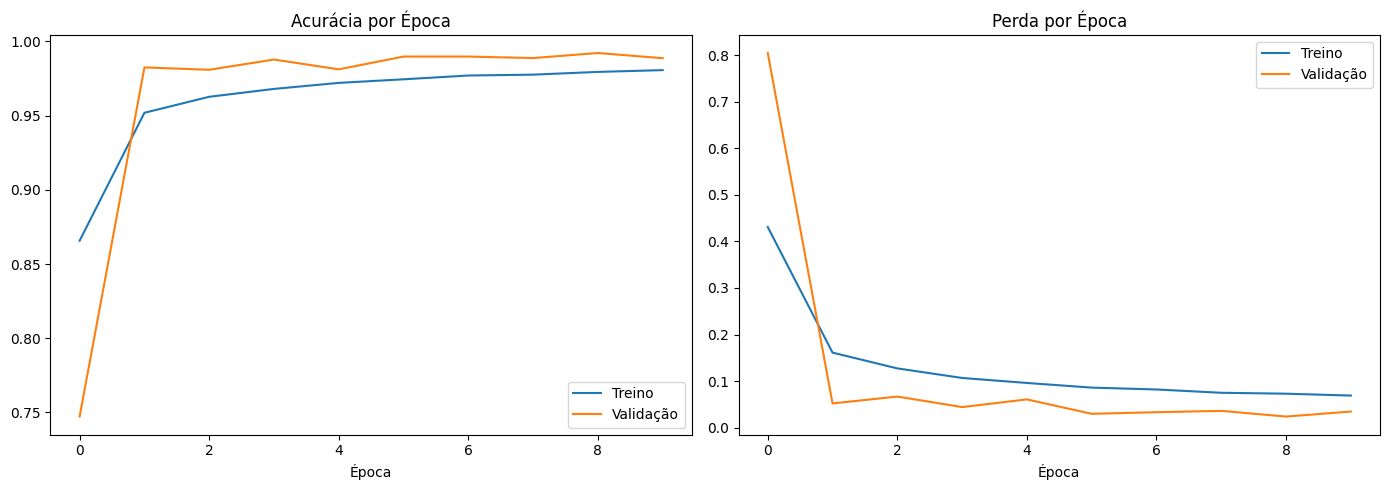

In [ ]:
# curvas de treinamento
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(historico.history['accuracy'], label='Treino')
axes[0].plot(historico.history['val_accuracy'], label='Validação')
axes[0].set_title('Acurácia por Época')
axes[0].set_xlabel('Época')
axes[0].legend()

axes[1].plot(historico.history['loss'], label='Treino')
axes[1].plot(historico.history['val_loss'], label='Validação')
axes[1].set_title('Perda por Época')
axes[1].set_xlabel('Época')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# avaliação final
resultado = classificador.evaluate(X_teste, y_teste)
print(f'Acurácia: {resultado[1]:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9867 - loss: 0.0408
Acurácia: 0.9887
